# LSTM Classifier — Side Experiment: Forecasting `Fault_Within_12h`

**Not a change to the locked primary metric.** `Capstone_Project_Plan.md`'s "Business goal & metric" section stays `Fault_Within_6h` — coach-approved 2026-07-28, not revisited here. This notebook exists purely to answer one question: **does forecasting further out, with a less extreme class imbalance (17.0% positive at 12h vs. 9.0% at 6h), make the pattern easier for the LSTM specifically?** If it does, that's interesting context for a future coach conversation about the metric — it is not itself a proposal to switch.

Mirrors `04_lstm_classifier.ipynb` exactly — same architecture, same hyperparameters, same chronological per-vehicle split methodology, same deferred-import discipline (see below) — with only the target and data source changed, so that any difference in results is attributable to the target/data, not to a different model or methodology.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_HOURS = 24
N_FEATURES = 4  # Motor_RPM, Motor_Torque, Motor_Temp, Battery_Temp

# matplotlib/seaborn/sklearn.metrics deliberately NOT imported here -- same reason as
# 04_lstm_classifier.ipynb: importing them in this kernel before model.fit() reliably
# deadlocks it on this machine (confirmed by direct isolation testing). Imported later,
# in the Evaluation section, after training has finished.

## 1. Load prepared 12h windows from `04a_lstm_windows.ipynb` (Section 4)

No pandas import in this notebook at all — same reason as `04_lstm_classifier.ipynb`. Data prep (windows, per-vehicle chronological split, scaling, class weights) already happened in `04a`'s side-experiment section and was saved to its own `.npz`.

In [2]:
data = np.load("../data/processed/lstm_fault_within_12h_windows.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
class_weight = {0: float(data["class_weight_0"]), 1: float(data["class_weight_1"])}

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean()*100:.3f}%, Test positive rate: {y_test.mean()*100:.3f}%")
print("Class weights (from y_train only, computed in 04a):", class_weight)

X_train: (139988, 24, 4), X_test: (34976, 24, 4)
Train positive rate: 17.001%, Test positive rate: 17.818%
Class weights (from y_train only, computed in 04a): {0: 0.6024150306827669, 1: 2.9410479431908905}


## 2. Build and train the same small LSTM

Identical architecture and hyperparameters to `04_lstm_classifier.ipynb` (2 LSTM layers, 64/32 units, dropout 0.2, sigmoid output) — deliberately unchanged, so any difference in results traces back to the target/data, not a different model. Built and compiled in its own cell, separate from `.fit()`, for the same reason documented in `04_lstm_classifier.ipynb`.

In [3]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW_HOURS, N_FEATURES)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.Recall(name="recall"), keras.metrics.Precision(name="precision")],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Same rationale as 04_lstm_classifier.ipynb: carve a proper random, stratified validation
# split out of the training fold (not Keras's validation_split, which would take a trailing
# slice that's entirely one vehicle's windows here).
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_fit, y_fit.astype("float32"),
    validation_data=(X_val, y_val.astype("float32")),
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/20


493/493 - 13s - 27ms/step - loss: 0.6355 - precision: 0.2645 - recall: 0.6423 - val_loss: 0.6216 - val_precision: 0.2677 - val_recall: 0.7059


Epoch 2/20


493/493 - 12s - 25ms/step - loss: 0.6289 - precision: 0.2624 - recall: 0.6737 - val_loss: 0.6137 - val_precision: 0.2703 - val_recall: 0.7004


Epoch 3/20


493/493 - 12s - 25ms/step - loss: 0.6265 - precision: 0.2639 - recall: 0.6772 - val_loss: 0.6206 - val_precision: 0.2703 - val_recall: 0.7139


Epoch 4/20


493/493 - 12s - 25ms/step - loss: 0.6243 - precision: 0.2656 - recall: 0.6758 - val_loss: 0.6192 - val_precision: 0.2708 - val_recall: 0.7181


Epoch 5/20


493/493 - 12s - 25ms/step - loss: 0.6226 - precision: 0.2658 - recall: 0.6784 - val_loss: 0.6183 - val_precision: 0.2648 - val_recall: 0.7277


## 3. Evaluation — default threshold, then tuned

`matplotlib`/`seaborn`/`sklearn.metrics` imported here for the first time, deliberately after `.fit()` — same reason as `04_lstm_classifier.ipynb`. Includes threshold tuning from the start this time (learned from `04`'s experience) rather than as an afterthought: sweep on validation, apply the chosen threshold to test exactly once.

Test windows: 34976 (6232.0 positive)

                precision    recall  f1-score   support

No fault (12h)      0.899     0.602     0.721     28744
   Fault (12h)      0.273     0.689     0.391      6232

      accuracy                          0.618     34976
     macro avg      0.586     0.646     0.556     34976
  weighted avg      0.788     0.618     0.662     34976



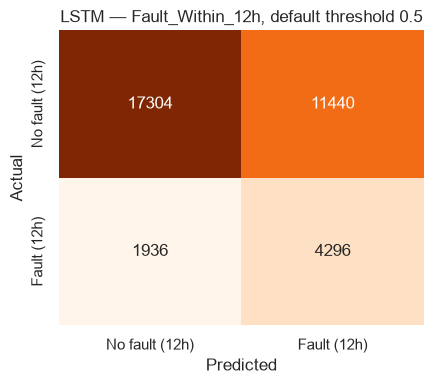

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

sns.set_theme(style="whitegrid")

y_pred_proba = model.predict(X_test, batch_size=512, verbose=0).ravel()
y_pred = y_pred_proba >= 0.5

print(f"Test windows: {len(y_test)} ({y_test.sum()} positive)")
print()
print(classification_report(y_test, y_pred, labels=[False, True], target_names=["No fault (12h)", "Fault (12h)"], digits=3))

lstm12h_macro_f1 = f1_score(y_test, y_pred, average="macro")
lstm12h_recall_positive = recall_score(y_test, y_pred, pos_label=True)

cm = confusion_matrix(y_test, y_pred, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (12h)", "Fault (12h)"],
            yticklabels=["No fault (12h)", "Fault (12h)"], cbar=False)
plt.title("LSTM — Fault_Within_12h, default threshold 0.5")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

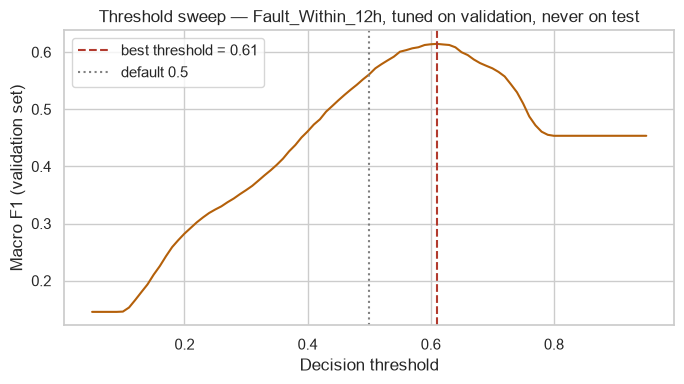

Best threshold on validation: 0.61 (macro F1 0.614 on validation)


In [6]:
# Threshold tuning, same technique as 04_lstm_classifier.ipynb -- sweep on validation only,
# apply the winning threshold to test exactly once.
y_val_proba = model.predict(X_val, batch_size=512, verbose=0).ravel()

thresholds = np.arange(0.05, 0.96, 0.01)
val_macro_f1s = [f1_score(y_val, y_val_proba >= t, average="macro") for t in thresholds]
best_threshold_12h = thresholds[int(np.argmax(val_macro_f1s))]

plt.figure(figsize=(7, 4))
plt.plot(thresholds, val_macro_f1s, color="#B4600A")
plt.axvline(best_threshold_12h, color="#B23A2E", linestyle="--", label=f"best threshold = {best_threshold_12h:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
plt.xlabel("Decision threshold")
plt.ylabel("Macro F1 (validation set)")
plt.title("Threshold sweep — Fault_Within_12h, tuned on validation, never on test")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold on validation: {best_threshold_12h:.2f} (macro F1 {max(val_macro_f1s):.3f} on validation)")

Test set, threshold=0.61 (chosen on validation, applied to test exactly once):

                precision    recall  f1-score   support

No fault (12h)      0.865     0.844     0.855     28744
   Fault (12h)      0.353     0.391     0.371      6232

      accuracy                          0.764     34976
     macro avg      0.609     0.618     0.613     34976
  weighted avg      0.774     0.764     0.768     34976



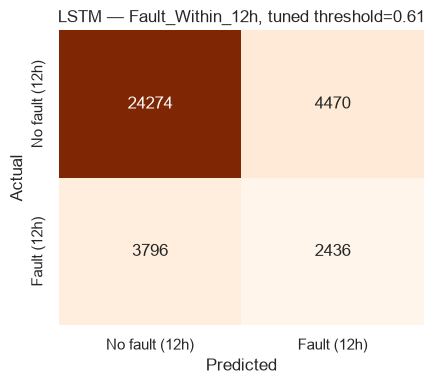


Macro F1: default-threshold 0.556 -> tuned-threshold 0.613
Fault-class recall: default-threshold 0.689 -> tuned-threshold 0.391


In [7]:
y_pred_tuned = y_pred_proba >= best_threshold_12h

print(f"Test set, threshold={best_threshold_12h:.2f} (chosen on validation, applied to test exactly once):")
print()
print(classification_report(y_test, y_pred_tuned, labels=[False, True], target_names=["No fault (12h)", "Fault (12h)"], digits=3))

lstm12h_macro_f1_tuned = f1_score(y_test, y_pred_tuned, average="macro")
lstm12h_recall_positive_tuned = recall_score(y_test, y_pred_tuned, pos_label=True)

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (12h)", "Fault (12h)"],
            yticklabels=["No fault (12h)", "Fault (12h)"], cbar=False)
plt.title(f"LSTM — Fault_Within_12h, tuned threshold={best_threshold_12h:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nMacro F1: default-threshold {lstm12h_macro_f1:.3f} -> tuned-threshold {lstm12h_macro_f1_tuned:.3f}")
print(f"Fault-class recall: default-threshold {lstm12h_recall_positive:.3f} -> tuned-threshold {lstm12h_recall_positive_tuned:.3f}")

## 4. All results side by side — with an important caveat

**Caveat first, before the numbers:** `Fault_Within_6h` and `Fault_Within_12h` are *different targets* over a *different subset of rows* (12h drops slightly more end-of-timeline rows) with a *different class balance* (9.0% vs. 17.0% positive). A higher or lower macro F1 on 12h doesn't mean the LSTM "got better at predicting" in any absolute sense — it means the 12h version of the problem is intrinsically easier or harder. The tree-baseline rows below are for `Fault_Within_6h` only (the locked primary metric) and are **not** a fair comparison point for the 12h LSTM rows — they're included for scale/context only.

In [8]:
# No pandas here either, same reason as 04_lstm_classifier.ipynb -- fit() already ran.
rows = [
    ("Random Forest, 6h (rolling/lag features)", 0.599, 0.594),
    ("XGBoost, 6h (rolling/lag features)", 0.594, 0.468),
    ("LSTM, 6h, default threshold 0.5", 0.504, 0.833),
    ("LSTM, 6h, tuned threshold 0.75", 0.604, 0.347),
    ("LSTM, 12h, default threshold 0.5", round(lstm12h_macro_f1, 3), round(lstm12h_recall_positive, 3)),
    (f"LSTM, 12h, tuned threshold {best_threshold_12h:.2f}", round(lstm12h_macro_f1_tuned, 3), round(lstm12h_recall_positive_tuned, 3)),
]
header = f"{'Model':<40} {'Macro F1':>10} {'Positive recall':>17}"
print(header)
print("-" * len(header))
for name, f1, recall in rows:
    print(f"{name:<40} {f1:>10.3f} {recall:>17.3f}")

Model                                      Macro F1   Positive recall
---------------------------------------------------------------------
Random Forest, 6h (rolling/lag features)      0.599             0.594
XGBoost, 6h (rolling/lag features)            0.594             0.468
LSTM, 6h, default threshold 0.5               0.504             0.833
LSTM, 6h, tuned threshold 0.75                0.604             0.347
LSTM, 12h, default threshold 0.5              0.556             0.689
LSTM, 12h, tuned threshold 0.61               0.613             0.391


## 5. Save the model

Saved separately from the 6h LSTM (`lstm_fault_within_6h.keras`) — a different target, not a replacement.

In [9]:
import os

os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_fault_within_12h.keras")
print("Saved to ../models/lstm_fault_within_12h.keras")

Saved to ../models/lstm_fault_within_12h.keras


## Summary

**Result: yes, the 12h target is genuinely easier for the LSTM — at every comparable operating point, not just one.**

| Model | Macro F1 | Fault-class recall |
|---|---|---|
| Random Forest, 6h (locked primary metric, context only) | 0.599 | 0.594 |
| XGBoost, 6h (locked primary metric, context only) | 0.594 | 0.468 |
| LSTM, 6h, default threshold 0.5 | 0.504 | 0.833 |
| LSTM, 6h, tuned threshold 0.75 | 0.604 | 0.347 |
| LSTM, 12h, default threshold 0.5 | 0.556 | 0.689 |
| LSTM, 12h, tuned threshold 0.61 | **0.613** | 0.391 |

Two things support "genuinely easier," not just "different numbers":

1. **At the default threshold**, the 12h model already lands at a more balanced operating point (27.3% precision / 68.9% recall) than the 6h model's extreme skew (17.0% precision / 83.3% recall) — the model isn't just being pushed toward one extreme by `class_weight` the way the 6h one is (the 12h class weights are milder, 2.94x vs. 5.57x, since the classes are less imbalanced to begin with).
2. **After tuning**, 12h's best macro F1 (0.613) edges out 6h's best (0.604) — and does so at meaningfully higher recall (39.1% vs. 34.7%), not by trading more recall away for it.

**The caveat that matters most:** this is not evidence that the *product* should switch to a 12h forecast window — `Fault_Within_6h` is still the locked, coach-approved primary metric, and changing it needs a coach conversation, not a unilateral swap based on one experiment. What this *does* show: the LSTM's weaker showing on the primary 6h metric isn't a sign the architecture is a poor fit for this problem in general — on a slightly different cut of the same underlying question, it's the best macro F1 in the whole comparison. Worth bringing to the coach as a data point, not as a fait accompli.

**What's next, if pursued:** a hybrid or ensemble approach (e.g. training on 12h but evaluating operationally against a 6h decision window) is one direction; so is trying whether the tree baselines show the same easier-at-12h pattern (not tested here — this notebook only covers the LSTM side, since that's what "try something else" was about).